In [12]:
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import matplotlib.cm as cm

$$-\Big(\frac{\partial^2 u}{\partial x_1^2} + \frac{\partial^2 u}{\partial x_2^2}\Big)+u= u|u|^{p-2}, \quad p>2$$
Where $u: \mathbb{S}^2 \to \mathbb{R}$

In [5]:
p = 3

def loss_fn(model, x, y, z, x0, y0, z0, u0):
    u = model(x, y, z, x0, y0, z0, u0)
    dudx, dudy, dudz = torch.autograd.grad(u, [x, y, z], grad_outputs=torch.ones_like(u), create_graph=True)
    d2udx2 = torch.autograd.grad(dudx, x, grad_outputs=torch.ones_like(dudx), create_graph=True)[0]
    d2udy2 = torch.autograd.grad(dudy, y, grad_outputs=torch.ones_like(dudy), create_graph=True)[0]
    d2udz2 = torch.autograd.grad(dudz, z, grad_outputs=torch.ones_like(dudz), create_graph=True)[0]
    laplacian = d2udx2 + d2udy2 + d2udz2
    return ((u * torch.abs(u)**(p-2) + laplacian - u)**2).mean()

In [36]:
def get_sin_cos(theta, phi):
    return [torch.sin(theta)*torch.cos(phi), torch.sin(theta)*torch.sin(phi), torch.cos(theta)]

class Model(nn.Module):
    def __init__(self, layer_size=256):
        super().__init__()
        self.nn = nn.Sequential(
            nn.Linear(7, layer_size), nn.Tanh(),
            nn.Linear(layer_size, layer_size), nn.Tanh(),
            nn.Linear(layer_size, layer_size), nn.Tanh(),
            nn.Linear(layer_size, layer_size), nn.Tanh(),
            nn.Linear(layer_size, layer_size), nn.Tanh(),
            nn.Linear(layer_size, layer_size), nn.Tanh(),
            nn.Linear(layer_size, layer_size), nn.Tanh(),
            nn.Linear(layer_size, layer_size), nn.Tanh(),
            nn.Linear(layer_size, 1)
        )

    def forward(self, x, y, z, x0, y0, z0, u0):
        return (self.nn(torch.concatenate([x, y, z, x0, y0, z0, u0], axis=-1)) * \
                (torch.abs(x) + torch.abs(y) + torch.abs(z-1))) * (torch.abs(x-x0) + torch.abs(y-y0) + torch.abs(z-z0))/(torch.abs(x0) + torch.abs(y0) + torch.abs(z0-1)) \
        + u0*(torch.abs(x)+torch.abs(y) + torch.abs(z-1))/(torch.abs(x0) + torch.abs(y0) + torch.abs(z0-1))

In [37]:
ones = torch.ones((1, 1))
model(ones*0, ones*0, ones, ones, ones, ones, 0.0*ones)

tensor([[0.0259]], grad_fn=<AddBackward0>)

In [38]:
torch.set_default_device('mps')
model = Model()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
#lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)

n_points = 1000
n_epochs = 1000
U_MAX = 2

for _ in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    
    theta0 = torch.rand((n_points, 1), requires_grad=True) * torch.pi
    u0 = (torch.rand((n_points, 1), requires_grad=True)) * U_MAX
    theta = torch.rand((n_points, 1), requires_grad=True) * torch.pi
    phi = torch.rand((n_points, 1), requires_grad=True) * 2*torch.pi
    
    loss = loss_fn(model, *get_sin_cos(theta, phi), *get_sin_cos(theta0, torch.zeros_like(theta0, requires_grad=True)), u0)
    loss.backward()
    optimizer.step()
    #lr_scheduler.step(loss)
    pbar.set_description(f"Loss: {loss.item():.4e}")

  0%|          | 0/1000 [00:00<?, ?it/s]

In [39]:
def plot_model(model, theta0, u0, xlim=(0, torch.pi), ylim=(0, 2*torch.pi), n=200, device=None):
    xs = torch.linspace(xlim[0], xlim[1], n, device=device)
    ys = torch.linspace(ylim[0], ylim[1], n, device=device)
    X, Y = torch.meshgrid(xs, ys, indexing="xy")
    x = X.reshape(-1, 1)
    y = Y.reshape(-1, 1)
    theta0_t = torch.full_like(x, float(theta0))
    u0_t = torch.full_like(x, float(u0))
    with torch.no_grad():
        out = model(*get_sin_cos(x, y), *get_sin_cos(theta0_t, torch.zeros_like(theta0_t)), u0_t)
    out = out.reshape(n, n, 1).cpu().numpy()
    X_np, Y_np = X.cpu().numpy(), Y.cpu().numpy()
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection='3d')
    m = cm.ScalarMappable(cmap='seismic')
    m.set_array(out[..., 0])
    im = ax.plot_surface(*get_sin_cos(torch.tensor(X_np), torch.tensor(Y_np)), facecolors = plt.get_cmap('seismic')(out[..., 0]), shade=False)
    fig.colorbar(m, ax=ax)
    ax.set_aspect('equal')
    plt.title(f"theta0 = {theta0}, phi0 = 0")
    plt.tight_layout()
    plt.show()

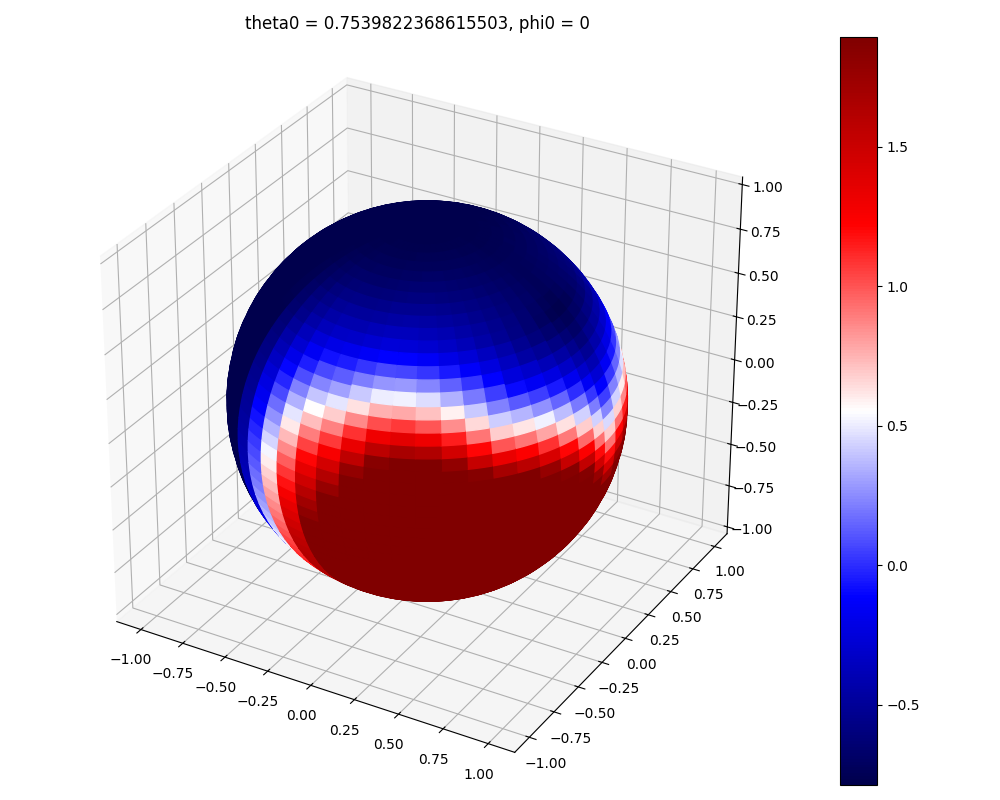

In [41]:
%matplotlib widget
plt.close()
torch.set_default_device('cpu')
plot_model(model.cpu(), theta0=6*torch.pi/25, u0=0)

In [42]:
n_points = 100

xs = torch.linspace(0, torch.pi, n_points, requires_grad=True)
ys = torch.linspace(0, 2*torch.pi, n_points, requires_grad=True)
X, Y = torch.meshgrid(xs, ys, indexing="xy")
x = X.reshape(-1, 1)
y = Y.reshape(-1, 1)
theta0 = torch.tensor([6*torch.pi/25], requires_grad=True).expand((n_points**2,1))
u0 = torch.tensor([15/25], requires_grad=True).expand((n_points**2, 1))

print(loss_fn(model, *get_sin_cos(x, y), *get_sin_cos(theta0, torch.zeros_like(theta0)), u0).mean().item())

7.896731376647949


In [15]:
torch.set_default_device('mps')
model.to('mps')
n_points = 50
xs = torch.linspace(0, torch.pi, n_points, requires_grad=True)
ys = torch.linspace(0, 2*torch.pi, n_points, requires_grad=True)
X, Y = torch.meshgrid(xs, ys, indexing="xy")
x = X.reshape(-1, 1)
y = Y.reshape(-1, 1)

theta0s = torch.linspace(0, torch.pi, n_points, requires_grad=True)
u0s = torch.linspace(0, 2, n_points, requires_grad=True)

losses = np.array([[loss_fn(model, *get_sin_cos(x, y), 
                   *get_sin_cos(torch.tensor(theta0, requires_grad=True).expand((n_points**2,1)), torch.tensor([0.], requires_grad=True).expand((n_points**2,1))), 
                   u0*torch.ones_like(torch.tensor(theta0, requires_grad=True).expand((n_points**2,1)))).item() for theta0 in theta0s] for u0 in tqdm(u0s)])

  0%|          | 0/50 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


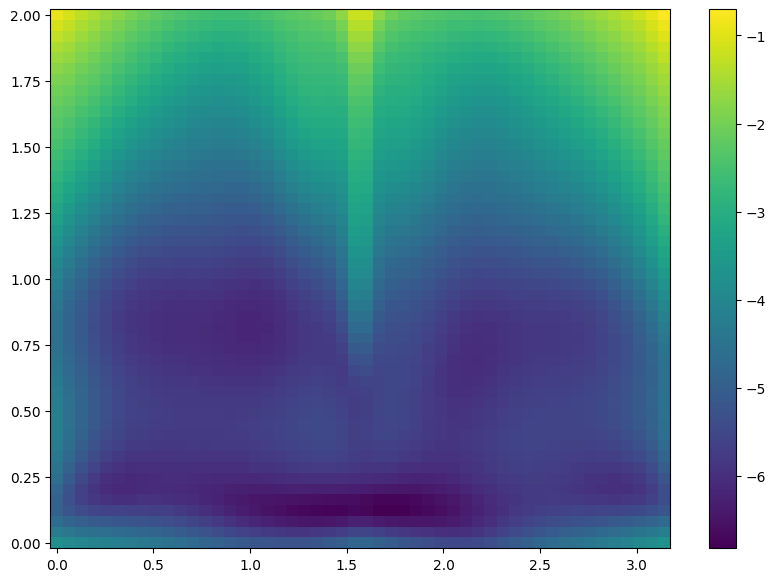

In [19]:
%matplotlib inline
plt.figure(figsize=(10, 7))
plt.pcolormesh(theta0s.detach().cpu().numpy(), u0s.detach().cpu().numpy(), np.log(losses))
plt.colorbar()
plt.show()

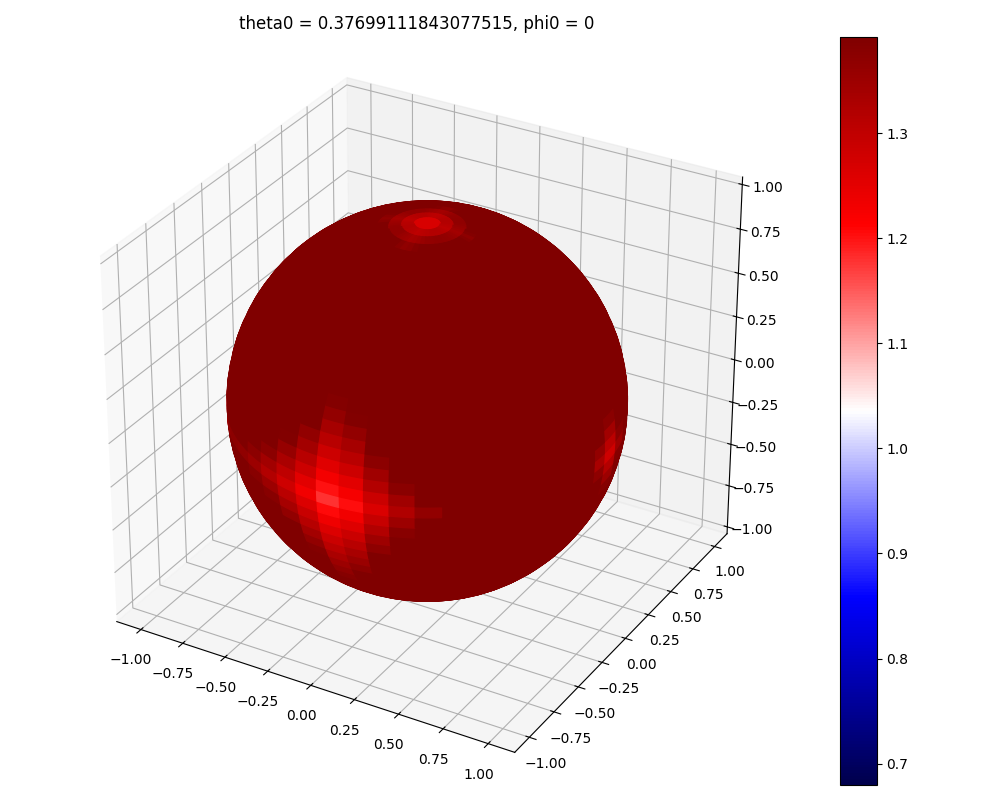

In [30]:
%matplotlib widget
plt.close()
torch.set_default_device('cpu')
u0, theta0 = ((np.argmin(losses)%n_points)*2/n_points, (np.argmin(losses)//n_points)*2*np.pi/n_points)
plot_model(model.cpu(), theta0=theta0, u0=u0)